\# Read and ploting EOVSA flare spectrogram and spectral imaging data

## Section 1: Download and read the data
* You can browse, query, and download the EOVSA spectrogram and spectral image data at https://ovsa.njit.edu/flarelist.
Alternatively, you can access them from the following direct links:
  * Spectrogram data can be accessed from
http://ovsa.njit.edu/events/ under directory YYYY with the name defined as “eovsa.spec.flare_id_YYYYMMDDHHMMSS.fits”
  * Spectral image data can be accessed from https://ovsa.njit.edu/fits/flares/ under YYYY/MM/DD[flare_id]/ with names “eovsa.lev1_mbd_12s.YYYY-MM-DDTHHMMSSZ.image.fits”
* The only Python package required in this section is Astropy (https://www.astropy.org/). One can install astropy with, e.g., "!pip install astropy"

In [ ]:
#Read EOVSA flare spectrogram FITS file
eospec_file = 'https://ovsa.njit.edu/events/2024/eovsa.spec.flare_id_20240210224700.fits'  # Use the path to your spec FITS file

from astropy.io import fits
from astropy.time import Time
eospecfits = fits.open(eospec_file)
# The spectrogram data has a shape of (n_freq, nt) in solar flux units (sfu)
spec = eospecfits[0].data
# Get the frequency axis in GHz
fghz = eospecfits[1].data['fghz']
# Get the time axis in julian date
eotime_jd = eospecfits[2].data['time']
eotime = Time(eotime_jd, format='jd')

In [ ]:
#Read EOVSA flare multi-frequency image FITS file
from astropy.io import fits
eofits = 'https://ovsa.njit.edu/fits/flares/2024/02/10/20240210224700/eovsa.lev1_mbd_12s.2024-02-10T224711Z.image.fits'  # Use the path to your image FITS file
hdu = fits.open(eofits)
# The image data is stored in the 2nd HDU (header data unit), index is 1. Dimension is (n_freq, ny, nx)
rdata = hdu[1].data
(nf, ny, nx) = rdata.shape
print('# of frequencies, # of pixels in y, # of pixels in x: {}, {}, {}'.format(nf, ny, nx))
# The frequency information is stored in the 3rd HDU (index 2) as a numpy record array
# 'cfreqs' is an array of the central frequency of each image in Hz
cfreqs_ghz = hdu[2].data['cfreqs'] / 1e9
# 'cdelts' is an array of the bandwidth of each image in Hz
bdw_ghz = hdu[2].data['cdelts'] /1e9

# Print the central frequencies of each image
print('Central frequencies in GHz: ', cfreqs_ghz)
print('Bandwidth in GHz: ', bdw_ghz)

# of frequencies, # of pixels in y, # of pixels in x: 9, 512, 512
Central frequencies in GHz:  [ 2.8737106  3.5208142  4.49208    5.1420646  6.7670255  8.391987
  9.691956  11.64191   13.2668705]
Bandwidth in GHz:  [0.32460937 0.32421875 0.325      0.325      0.325      0.325
 0.325      0.325      0.325     ]


## Section 2: Examples of plotting the spectrogram and spectral images

Now you are all set and can use your favorate method to plot the spectrograms and spectral images! In the following, we provide simple examples in doing that with matplotlib (https://matplotlib.org/) and sunpy (https://sunpy.org/). Experienced users can skip the following and jsut start to do science!

In [ ]:
# If SunPy is not already installed in your environment, uncomment the lines below to install it.

# It is recommended to install the latest version of SunPy directly from the official SunPy GitHub repository
# to ensure compatibility and access to the newest features.
!pip install git+https://github.com/sunpy/sunpy.git

# Additionally, to enable the functionality for downloading FITS files from various instruments including SDO/AIA,
# it is necessary to install the 'net' extra of SunPy. This provides the required dependencies for network operations.
!pip install sunpy[net]


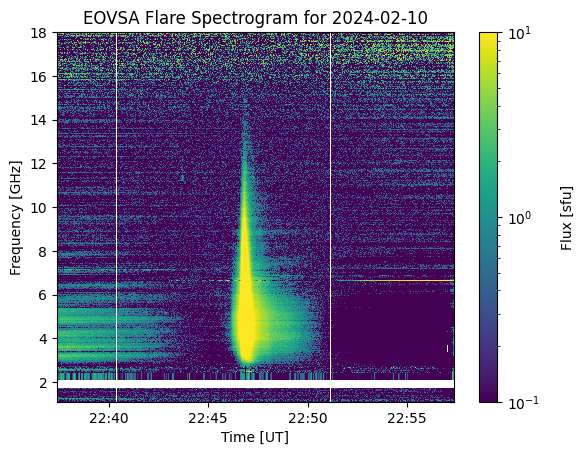

In [ ]:
# Example for plotting the EOVSA spectrogram
from astropy.time import Time
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.dates import AutoDateFormatter, AutoDateLocator

eotime_pd = eotime.plot_date
spec[spec <= 0] = 0.0001

fig = plt.figure()
ax = fig.add_subplot()
ph = ax.pcolormesh(eotime_pd, fghz, spec, cmap='viridis',
                   norm=mcolors.LogNorm(vmax=10, vmin=0.1))

ax.xaxis.set_major_locator(locator:= AutoDateLocator(minticks=5))
ax.xaxis.set_major_formatter(formatter:= AutoDateFormatter(locator))
formatter.scaled[1/(24*60)] = '%H:%M'

plt.setp(ax, xlabel='Time [UT]', ylabel='Frequency [GHz]',
         xlim=[eotime_pd[0], eotime_pd[-1]],
         title='EOVSA Flare Spectrogram for ' + eotime[0].isot[:10])

cbar = plt.colorbar(ph, ax=ax)
cbar.set_label('Flux [sfu]', labelpad=15)
plt.show()

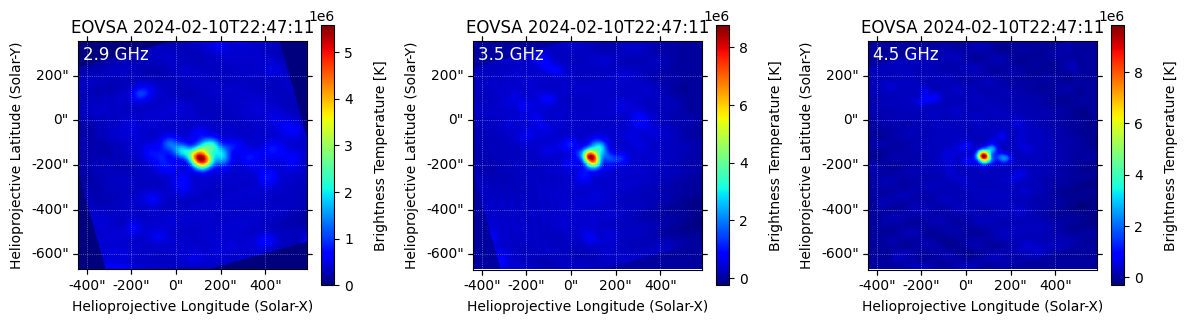

In [ ]:
# Example of using sunpy.map to plot the EOVSA flare images.
# Note that, at present, sunpy.map can only process one single 2D map at a time.
import sunpy.map
import matplotlib.pyplot as plt
 # select frequency indices to plot. We have 9 frequencies in this example
spws = [0, 1, 2]

fig = plt.figure(figsize=(12., 3.5))
for n, sp in enumerate(spws):
    data = rdata[sp,:,:]
    header = hdu[1].header
    rmap = sunpy.map.Map(data, header)
    ax = fig.add_subplot(1, len(spws), n+1, projection=rmap)
    rmap.plot(axes=ax, cmap=plt.get_cmap('jet'))
    rmap.draw_limb()
    ax.set_title('EOVSA ' + rmap.date.datetime.strftime('%Y-%m-%dT%H:%M:%S'))
    ax.text(0.02, 0.98, "{:.1f}".format(cfreqs_ghz[sp])+' GHz ',
            ha='left', va='top', transform=ax.transAxes, color='w', fontsize=12)
    cbar = plt.colorbar()
    cbar.set_label('Brightness Temperature [K]', labelpad=15)

plt.tight_layout()
plt.show()

**If you want to go more fancy and overlay multi-frequency EOVSA images on AIA. Here is an addional example.**

In [ ]:
## Download a AIA FITS file first using Sunpy Fido.
from sunpy.net import Fido, attrs as a
import astropy.units as u
from datetime import datetime, timedelta

eotplt = rmap.date

# Define the time range and wavelength
time = a.Time(eotplt, eotplt+timedelta(seconds=12))
wavelength = a.Wavelength(171 * u.angstrom)  # 171 angstroms for AIA 171

# Set up the search criteria for the AIA instrument
search_criteria = a.Instrument.aia & wavelength & time

# Perform the search
results = Fido.search(search_criteria)

# Print out the results to the user
print(results)

# Assuming you want to download the first result
downloaded_files = Fido.fetch(results[0, 0])

# Print the file path of the downloaded file
print(downloaded_files)




Results from 1 Provider:

1 Results from the VSOClient:
Source: http://vso.stanford.edu/cgi-bin/search
Total estimated size: 67.789 Mbyte

       Start Time               End Time        Source ... Extent Type   Size  
                                                       ...              Mibyte 
----------------------- ----------------------- ------ ... ----------- --------
2024-02-10 22:47:21.000 2024-02-10 22:47:22.000    SDO ...    FULLDISK 64.64844




Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

aia.lev1.171A_2024_02_10T22_47_21.35Z.image_lev1.fits:   0%|          | 0.00/12.5M [00:00<?, ?B/s]

['/root/sunpy/data/aia.lev1.171A_2024_02_10T22_47_21.35Z.image_lev1.fits']


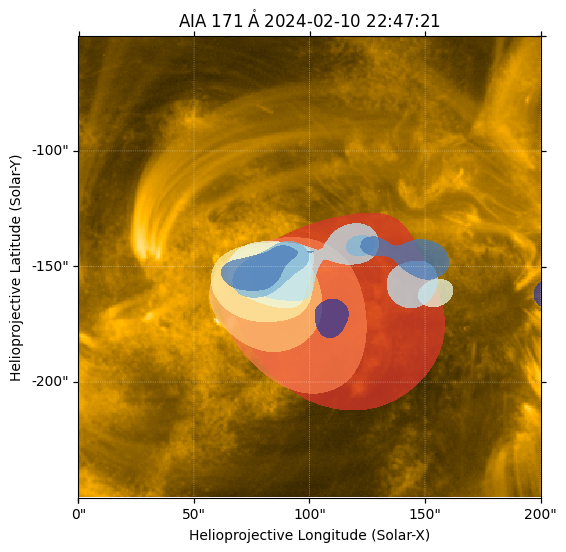

In [ ]:
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
import astropy.units as u
import sunpy.map

# This script demonstrates how to use sunpy.map to overlay EOVSA flare images
# at multiple frequencies on an AIA image using filled contour plots.

# Select the spectral window (SPW) frequencies for plotting
spw_to_plot = range(9)

# Load the first AIA file from the downloaded files and create a SunPy Map
aia_file = downloaded_files[0]
aia_map = sunpy.map.Map(aia_file)

# Initialize a figure with an AIA map projection
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(projection=aia_map)

# Display the AIA map
aia_map.plot(axes=ax)

# Define a colormap for plotting the EOVSA flare images
eocmap = plt.get_cmap('RdYlBu')

# Loop over each selected SPW to plot the EOVSA flare data
for n, spw in enumerate(spw_to_plot):
    data = rdata[spw, :, :]
    header = hdu[1].header
    eomap = sunpy.map.Map(data, header)

    # Plot filled contours for the EOVSA flare data
    # between 50% and 100% of the maximum intensity
    # of each map to highlight regions of peak emission.
    eomap.draw_contours(levels=[50, 100] * u.percent,
                            colors=[eocmap((n + 1) / len(spw_to_plot))],
                            fill=True, alpha=0.75, axes=ax)

# Define the region of interest around the flare site in arcseconds
x_range = [0, 200] * u.arcsec
y_range = [-250, -50] * u.arcsec

# Convert world coordinates to pixel coordinates for the AIA map
world_coords = SkyCoord(Tx=x_range, Ty=y_range, frame=aia_map.coordinate_frame)
pixel_coords_x, pixel_coords_y = aia_map.wcs.world_to_pixel(world_coords)

# Set the plot limits to focus on the flare site
ax.set_xlim(pixel_coords_x)
ax.set_ylim(pixel_coords_y)

# Display the plot
plt.show()
